# Phase 2 — Exploratory Data Analysis (M5 bootstrap)

Reproducible EDA over the staged canonical data. Findings memo: `docs/PHASE2_eda_findings.md`.
Each section ends with the design decision it feeds (Phases 3-7).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import duckdb, pandas as pd, matplotlib.pyplot as plt
from src.config import CONFIG

con = duckdb.connect(); con.execute('PRAGMA threads=4;')
STAGED = (CONFIG.data_dir / 'staged').as_posix()
SALES = f"read_parquet('{STAGED}/sales_transactions/**/*.parquet')"
CAL   = f"read_parquet('{STAGED}/external_calendar.parquet')"
SEG   = f"read_parquet('{(CONFIG.data_dir/'features'/'segments.parquet').as_posix()}')"
print('horizon', CONFIG.horizon, '| quantiles', CONFIG.quantiles)

horizon 14 | quantiles [0.5, 0.9, 0.95]


## 2.1 Data-quality audit

In [2]:
con.execute(f'''SELECT count(*) n_rows, count(DISTINCT sku_id) skus, count(DISTINCT store_id) stores,
  min(date) min_date, max(date) max_date,
  round(100.0*avg(CASE WHEN qty=0 THEN 1 ELSE 0 END),1) pct_zero_days,
  sum(CASE WHEN qty<0 THEN 1 ELSE 0 END) negative_qty_rows
  FROM {SALES}''').df()

,n_rows,skus,stores,min_date,max_date,pct_zero_days,negative_qty_rows
0,46881677,3049,10,2011-01-29,2016-05-22,59.6,0.0


## 2.2 Intermittency classification (ADI / CV2) — the key output
Drives model routing (Phase 5.7).

,intermittency,n,pct,revenue
0,intermittent,22143,72.6,98803478.0
1,lumpy,5612,18.4,31765797.0
2,smooth,1880,6.2,46308093.0
3,erratic,855,2.8,14700178.0


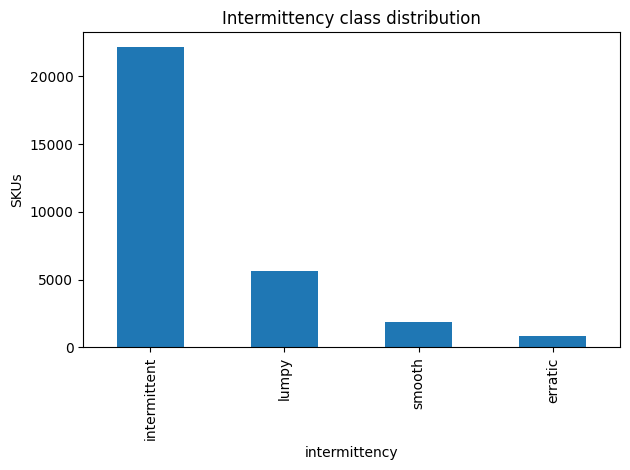

In [3]:
dist = con.execute(f'''SELECT intermittency, count(*) n,
  round(100.0*count(*)/sum(count(*)) OVER (),1) pct, round(sum(revenue),0) revenue
  FROM {SEG} GROUP BY 1 ORDER BY n DESC''').df()
display(dist)
dist.set_index('intermittency')['n'].plot.bar(title='Intermittency class distribution'); plt.ylabel('SKUs'); plt.tight_layout(); plt.show()

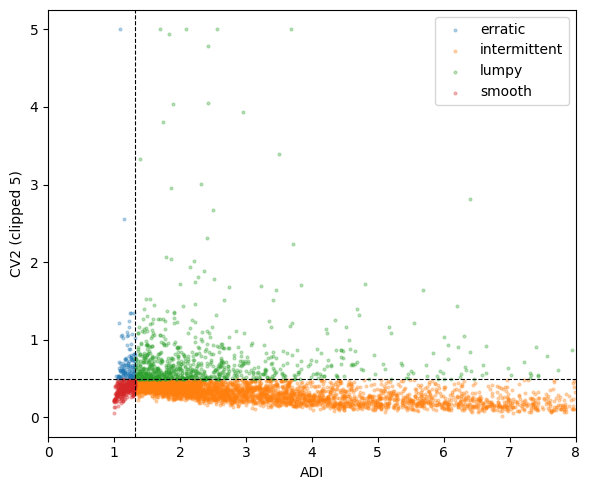

In [4]:
# ADI vs CV^2 scatter with Syntetos-Boylan quadrants
s = con.execute(f'SELECT adi, cv2, intermittency FROM {SEG} WHERE adi IS NOT NULL AND cv2 IS NOT NULL USING SAMPLE 5000').df()
fig, ax = plt.subplots(figsize=(6,5))
for cls, g in s.groupby('intermittency'):
    ax.scatter(g.adi, g.cv2.clip(upper=5), s=4, alpha=0.3, label=cls)
ax.axvline(1.32, color='k', ls='--', lw=0.8); ax.axhline(0.49, color='k', ls='--', lw=0.8)
ax.set_xlabel('ADI'); ax.set_ylabel('CV2 (clipped 5)'); ax.set_xlim(0,8); ax.legend(); plt.tight_layout(); plt.show()

## 2.3 Seasonality — day-of-week

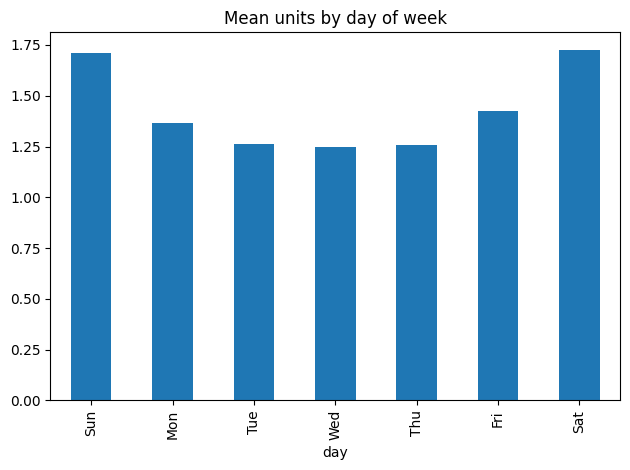

In [5]:
dow = con.execute(f'SELECT dayofweek(date) dow, round(avg(qty),3) mean_units FROM {SALES} GROUP BY 1 ORDER BY 1').df()
dow['day'] = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
dow.set_index('day')['mean_units'].plot.bar(title='Mean units by day of week'); plt.tight_layout(); plt.show()

## 2.4 ABC x XYZ 9-box

In [6]:
box = con.execute(f'SELECT abc, xyz, count(*) n FROM {SEG} GROUP BY 1,2').df()
display(box.pivot(index='abc', columns='xyz', values='n'))
con.execute(f'''SELECT abc, count(*) skus, round(100.0*sum(revenue)/sum(sum(revenue)) OVER (),1) rev_pct
  FROM {SEG} GROUP BY 1 ORDER BY 1''').df()

xyz,X,Y,Z
abc,,,
A,83.0,2730.0,8751.0
B,NaN,265.0,9089.0
C,NaN,53.0,9519.0


,abc,skus,rev_pct
0,A,11564,80.0
1,B,9354,15.0
2,C,9572,5.0


## 2.7 External drivers — SNAP (salary-window proxy) & holidays

In [7]:
con.execute(f'''SELECT cal.salary_window, cal.is_holiday, round(avg(s.qty),3) mean_units, count(*) n
  FROM {SALES} s JOIN {CAL} cal ON s.date=cal.date AND substr(s.store_id,1,2)=cal.region
  GROUP BY 1,2 ORDER BY 1,2''').df()

,salary_window,is_holiday,mean_units,n
0,False,False,1.375,28969566
1,False,True,1.297,2480465
2,True,False,1.551,14103761
3,True,True,1.508,1327885
